## Get the dataset

This classification algorithm will be trained and run on "gpiosenka/cards-image-datasetclassification" available to download directly at https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification/data or by using the kaggle api through CLI with the commands in bash: 

 1. kaggle datasets download gpiosenka/cards-image-datasetclassification ; dataset will be downloaded as zip

 2. unzip "cards-image-datasetclassification.zip" -d "desired-folder/" ; unzip to desired dataset folder
 
 3. rm "cards-image-datasetclassification.zip" ; remove zip


In [33]:
# get libs

import torch 
import torch.nn as nn 
import torch.optim as optim # Optimizers
from torch.utils.data import Dataset, DataLoader # Data conversion to tensor format and batches
import torchvision
import torchvision.transforms as transforms # Rescaling img and convrtig to tensor
from torchvision.datasets import ImageFolder
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import gc
import sys


print('System Version:', sys.version)
print('PyTorch version', torch.__version__)
print('Torchvision version', torchvision.__version__)
print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)

System Version: 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]
PyTorch version 2.7.0+cu128
Torchvision version 0.22.0+cu128
Numpy version 2.1.3
Pandas version 2.2.3


In [34]:
# Check device availability
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


## Prepare Datasets and DataLoader

In [35]:
#Define data collector
class CardCollector(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = ImageFolder(data_dir, transform=transform)

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]
    
    @property
    def classes(self):
        return self.data.classes

In [36]:
data_train = "D:/#Git/neural-networks-playground/datadir/cards-image-dataset/train"
data_valid = "D:/#Git/neural-networks-playground/datadir/cards-image-dataset/valid"
data_test = "D:/#Git/neural-networks-playground/datadir/cards-image-dataset/test"

# Recommended to employ a better training routine, resulting in a more robust dataset
train_tf = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

tf = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

train = CardCollector(data_dir=data_train, transform=train_tf)
valid = CardCollector(data_dir=data_valid, transform=tf)
test  = CardCollector(data_dir=data_test , transform=tf)

batch_size = 64 # A standard is 32 but you can add a bigger one based on availabe GPU memory

train_loader = DataLoader(train, batch_size=batch_size, shuffle= True) # Shuffle only active on training set, no real difference if we also shuffle on validation or test
valid_loader = DataLoader(valid, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test , batch_size=batch_size, shuffle=False)

In [37]:
train[45] # Take a look at the new tensor

(tensor([[[0.0353, 0.0353, 0.0353,  ..., 0.0353, 0.0353, 0.0353],
          [0.0353, 0.0353, 0.0353,  ..., 0.0353, 0.0353, 0.0353],
          [0.0353, 0.0353, 0.0353,  ..., 0.0353, 0.0353, 0.0353],
          ...,
          [0.0353, 0.0353, 0.0353,  ..., 0.0353, 0.0353, 0.0353],
          [0.0353, 0.0353, 0.0353,  ..., 0.0353, 0.0353, 0.0353],
          [0.0353, 0.0353, 0.0353,  ..., 0.0353, 0.0353, 0.0353]],
 
         [[0.0353, 0.0353, 0.0353,  ..., 0.0353, 0.0353, 0.0353],
          [0.0353, 0.0353, 0.0353,  ..., 0.0353, 0.0353, 0.0353],
          [0.0353, 0.0353, 0.0353,  ..., 0.0353, 0.0353, 0.0353],
          ...,
          [0.0353, 0.0353, 0.0353,  ..., 0.0353, 0.0353, 0.0353],
          [0.0353, 0.0353, 0.0353,  ..., 0.0353, 0.0353, 0.0353],
          [0.0353, 0.0353, 0.0353,  ..., 0.0353, 0.0353, 0.0353]],
 
         [[0.0353, 0.0353, 0.0353,  ..., 0.0353, 0.0353, 0.0353],
          [0.0353, 0.0353, 0.0353,  ..., 0.0353, 0.0353, 0.0353],
          [0.0353, 0.0353, 0.0353,  ...,

In [38]:
print("\t----- Before Dataloading -----")
print(len(train))

image, label = train[345]
print(label)
print(image.shape)

print("\t----- After Dataloading -----")
for image_loaded, label_loaded in train_loader:
    break

print(image_loaded.shape, label_loaded.shape)
print(label_loaded)

	----- Before Dataloading -----
7624
2
torch.Size([3, 128, 128])
	----- After Dataloading -----
torch.Size([64, 3, 128, 128]) torch.Size([64])
tensor([ 1,  7,  1, 41, 29,  1, 49, 44,  5,  9, 41,  3, 35, 20, 22,  9,  3, 44,
         2, 18, 20,  3, 45, 38, 52, 49, 20,  7, 31, 24,  0, 35,  9, 22,  6, 38,
        37, 21, 43, 14,  4, 36,  2,  4, 16, 49, 44,  4, 15, 11, 11,  5, 28,  4,
        43, 29, 46, 28, 16,  9, 37, 27,  3, 35])


In [39]:
for image, label in train_loader:
    break    

print(image.shape)

image_lookup = image[0, :, :, :]
image_lookup.shape
print(image_lookup)

torch.Size([64, 3, 128, 128])
tensor([[[0.0000, 0.0000, 0.9765,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.9843,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.9843,  ..., 0.9765, 0.9922, 0.9922],
         ...,
         [0.9843, 0.9922, 0.9804,  ..., 0.9922, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.9922, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.9922, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.9843,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.9922,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.9922,  ..., 0.9725, 0.9843, 0.9922],
         ...,
         [0.9922, 0.9922, 0.9922,  ..., 0.9922, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.9922, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.9922, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.9137,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.9137,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.

In [40]:
class_labels = {v:k for k, v in ImageFolder(data_train).class_to_idx.items()}
print(class_labels)

{0: 'ace of clubs', 1: 'ace of diamonds', 2: 'ace of hearts', 3: 'ace of spades', 4: 'eight of clubs', 5: 'eight of diamonds', 6: 'eight of hearts', 7: 'eight of spades', 8: 'five of clubs', 9: 'five of diamonds', 10: 'five of hearts', 11: 'five of spades', 12: 'four of clubs', 13: 'four of diamonds', 14: 'four of hearts', 15: 'four of spades', 16: 'jack of clubs', 17: 'jack of diamonds', 18: 'jack of hearts', 19: 'jack of spades', 20: 'joker', 21: 'king of clubs', 22: 'king of diamonds', 23: 'king of hearts', 24: 'king of spades', 25: 'nine of clubs', 26: 'nine of diamonds', 27: 'nine of hearts', 28: 'nine of spades', 29: 'queen of clubs', 30: 'queen of diamonds', 31: 'queen of hearts', 32: 'queen of spades', 33: 'seven of clubs', 34: 'seven of diamonds', 35: 'seven of hearts', 36: 'seven of spades', 37: 'six of clubs', 38: 'six of diamonds', 39: 'six of hearts', 40: 'six of spades', 41: 'ten of clubs', 42: 'ten of diamonds', 43: 'ten of hearts', 44: 'ten of spades', 45: 'three of clu

## Build Classifier Model

In [41]:
ch_size = 3 # number of initial channel, 3 for RGB 
out_size = 53 # number of classes to predict

class ImgClassif(nn.Module):
    def __init__(self, n_classes = 53):
        super(ImgClassif, self).__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(ch_size, 32, (3,3), padding=1),              # 1st Conv layer
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, (3,3), padding=1),                   # 2nd Conv Layer
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, (3,3), padding=1),                  # 3rd Conv layer
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
        )
       
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),
            
            nn.Linear(128, out_size)
            # nn.Softmax() -- No need for softmax as we will use CrossEntropyLoss which combines LogSoftmax and NNLoss
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        out = self.classifier(features)
        return out



In [42]:
# Print the model
model = ImgClassif()
print(model)

t_params = sum(p.numel() for p in model.parameters())
print(f"Total number of learnable parameters in the ImageClassif model: {t_params}")

ImgClassif(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): BatchNorm1d

## Define training program

In [43]:
# Run this befor retraining a model to free up space on GPU

torch.cuda.empty_cache()
gc.collect()

109317

In [45]:
n_epochs = 30
train_losses, val_losses = [], []

model = ImgClassif(n_classes=53)
model.to(device)

# Always be carefull to initialize optimizer after defining the model, otherwise you will train on past gradients
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                 mode='min',
                                                 patience=2,
                                                 factor=0.1)
                                                 # Decreasing the LR if no Loss reduction after 2 epochs

for epoch in range(n_epochs):
    # Training phase -- good practice to switch model to train/eval states 
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc='Training loop'):
        # Send batches to device
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels) # Compute loss
        loss.backward()                   # Send backpropagation and compute gradients
        optimizer.step()                  # Update model parameters
        running_loss += loss.item() * labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validation phase
    model.eval()
    running_loss = 0.0
    
    with torch.no_grad():
        for images, labels in tqdm(valid_loader, desc='Validation loop'):
            # Send batches to device
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)

    val_loss = running_loss / len(valid_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch + 1}/{n_epochs} - Train loss: {train_loss}, Validation loss: {val_loss}")
    scheduler.step(val_loss) # Monitors the Loss values after each epoch

    

Training loop:   0%|          | 0/120 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/30 - Train loss: 3.083292011449119, Validation loss: 1.9789782821007496


Training loop:   0%|          | 0/120 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/5 [00:00<?, ?it/s]

...

Validation loop:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 29/30 - Train loss: 0.20149246593087067, Validation loss: 0.31306094957410163


Training loop:   0%|          | 0/120 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 30/30 - Train loss: 0.19529251571342052, Validation loss: 0.30525444211824887


## Vizualise losses

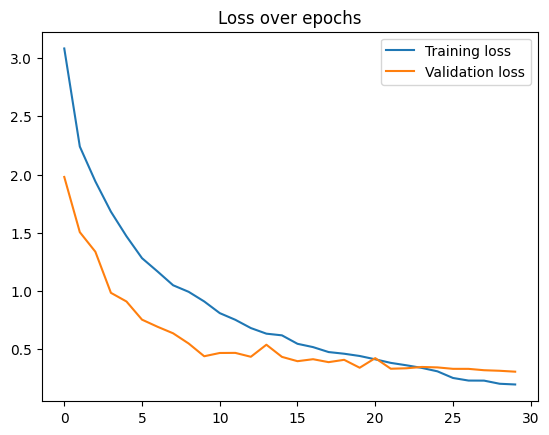

In [46]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

## Checking results on the test set

In [47]:
def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Testing'):
            images, labels = images.to(device), labels.to(device)
            
            
            outputs = model(images)
            
            
            loss = criterion(outputs, labels)
            test_loss += loss.item() * labels.size(0)
            
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    
    avg_loss = test_loss / len(test_loader.dataset)
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy


test_loss, test_accuracy = evaluate_model(model, test_loader, criterion, device)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.2f}%')


def show_predictions(model, test_loader, class_labels, num_samples=30):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images[:num_samples].to(device), labels[:num_samples].to(device)
    
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
    # Convert indices to class names
    predicted_classes = [class_labels[p.item()] for p in predicted]
    true_classes = [class_labels[l.item()] for l in labels]
    
    print("\nSample Predictions:")
    for i in range(num_samples):
        print(f"True: {true_classes[i]:<20} Predicted: {predicted_classes[i]:<20}")


show_predictions(model, test_loader, class_labels)

Testing:   0%|          | 0/5 [00:00<?, ?it/s]

Test Loss: 0.4927
Test Accuracy: 86.79%

Sample Predictions:
True: ace of clubs         Predicted: ace of clubs        
True: ace of clubs         Predicted: ace of clubs        
True: ace of clubs         Predicted: ace of clubs        
True: ace of clubs         Predicted: ace of clubs        
True: ace of clubs         Predicted: ace of clubs        
True: ace of diamonds      Predicted: ace of diamonds     
True: ace of diamonds      Predicted: ace of diamonds     
True: ace of diamonds      Predicted: ace of diamonds     
True: ace of diamonds      Predicted: ace of diamonds     
True: ace of diamonds      Predicted: ace of diamonds     
True: ace of hearts        Predicted: ace of hearts       
True: ace of hearts        Predicted: ace of hearts       
True: ace of hearts        Predicted: ace of hearts       
True: ace of hearts        Predicted: ace of hearts       
True: ace of hearts        Predicted: ace of hearts       
True: ace of spades        Predicted: ace of spades   

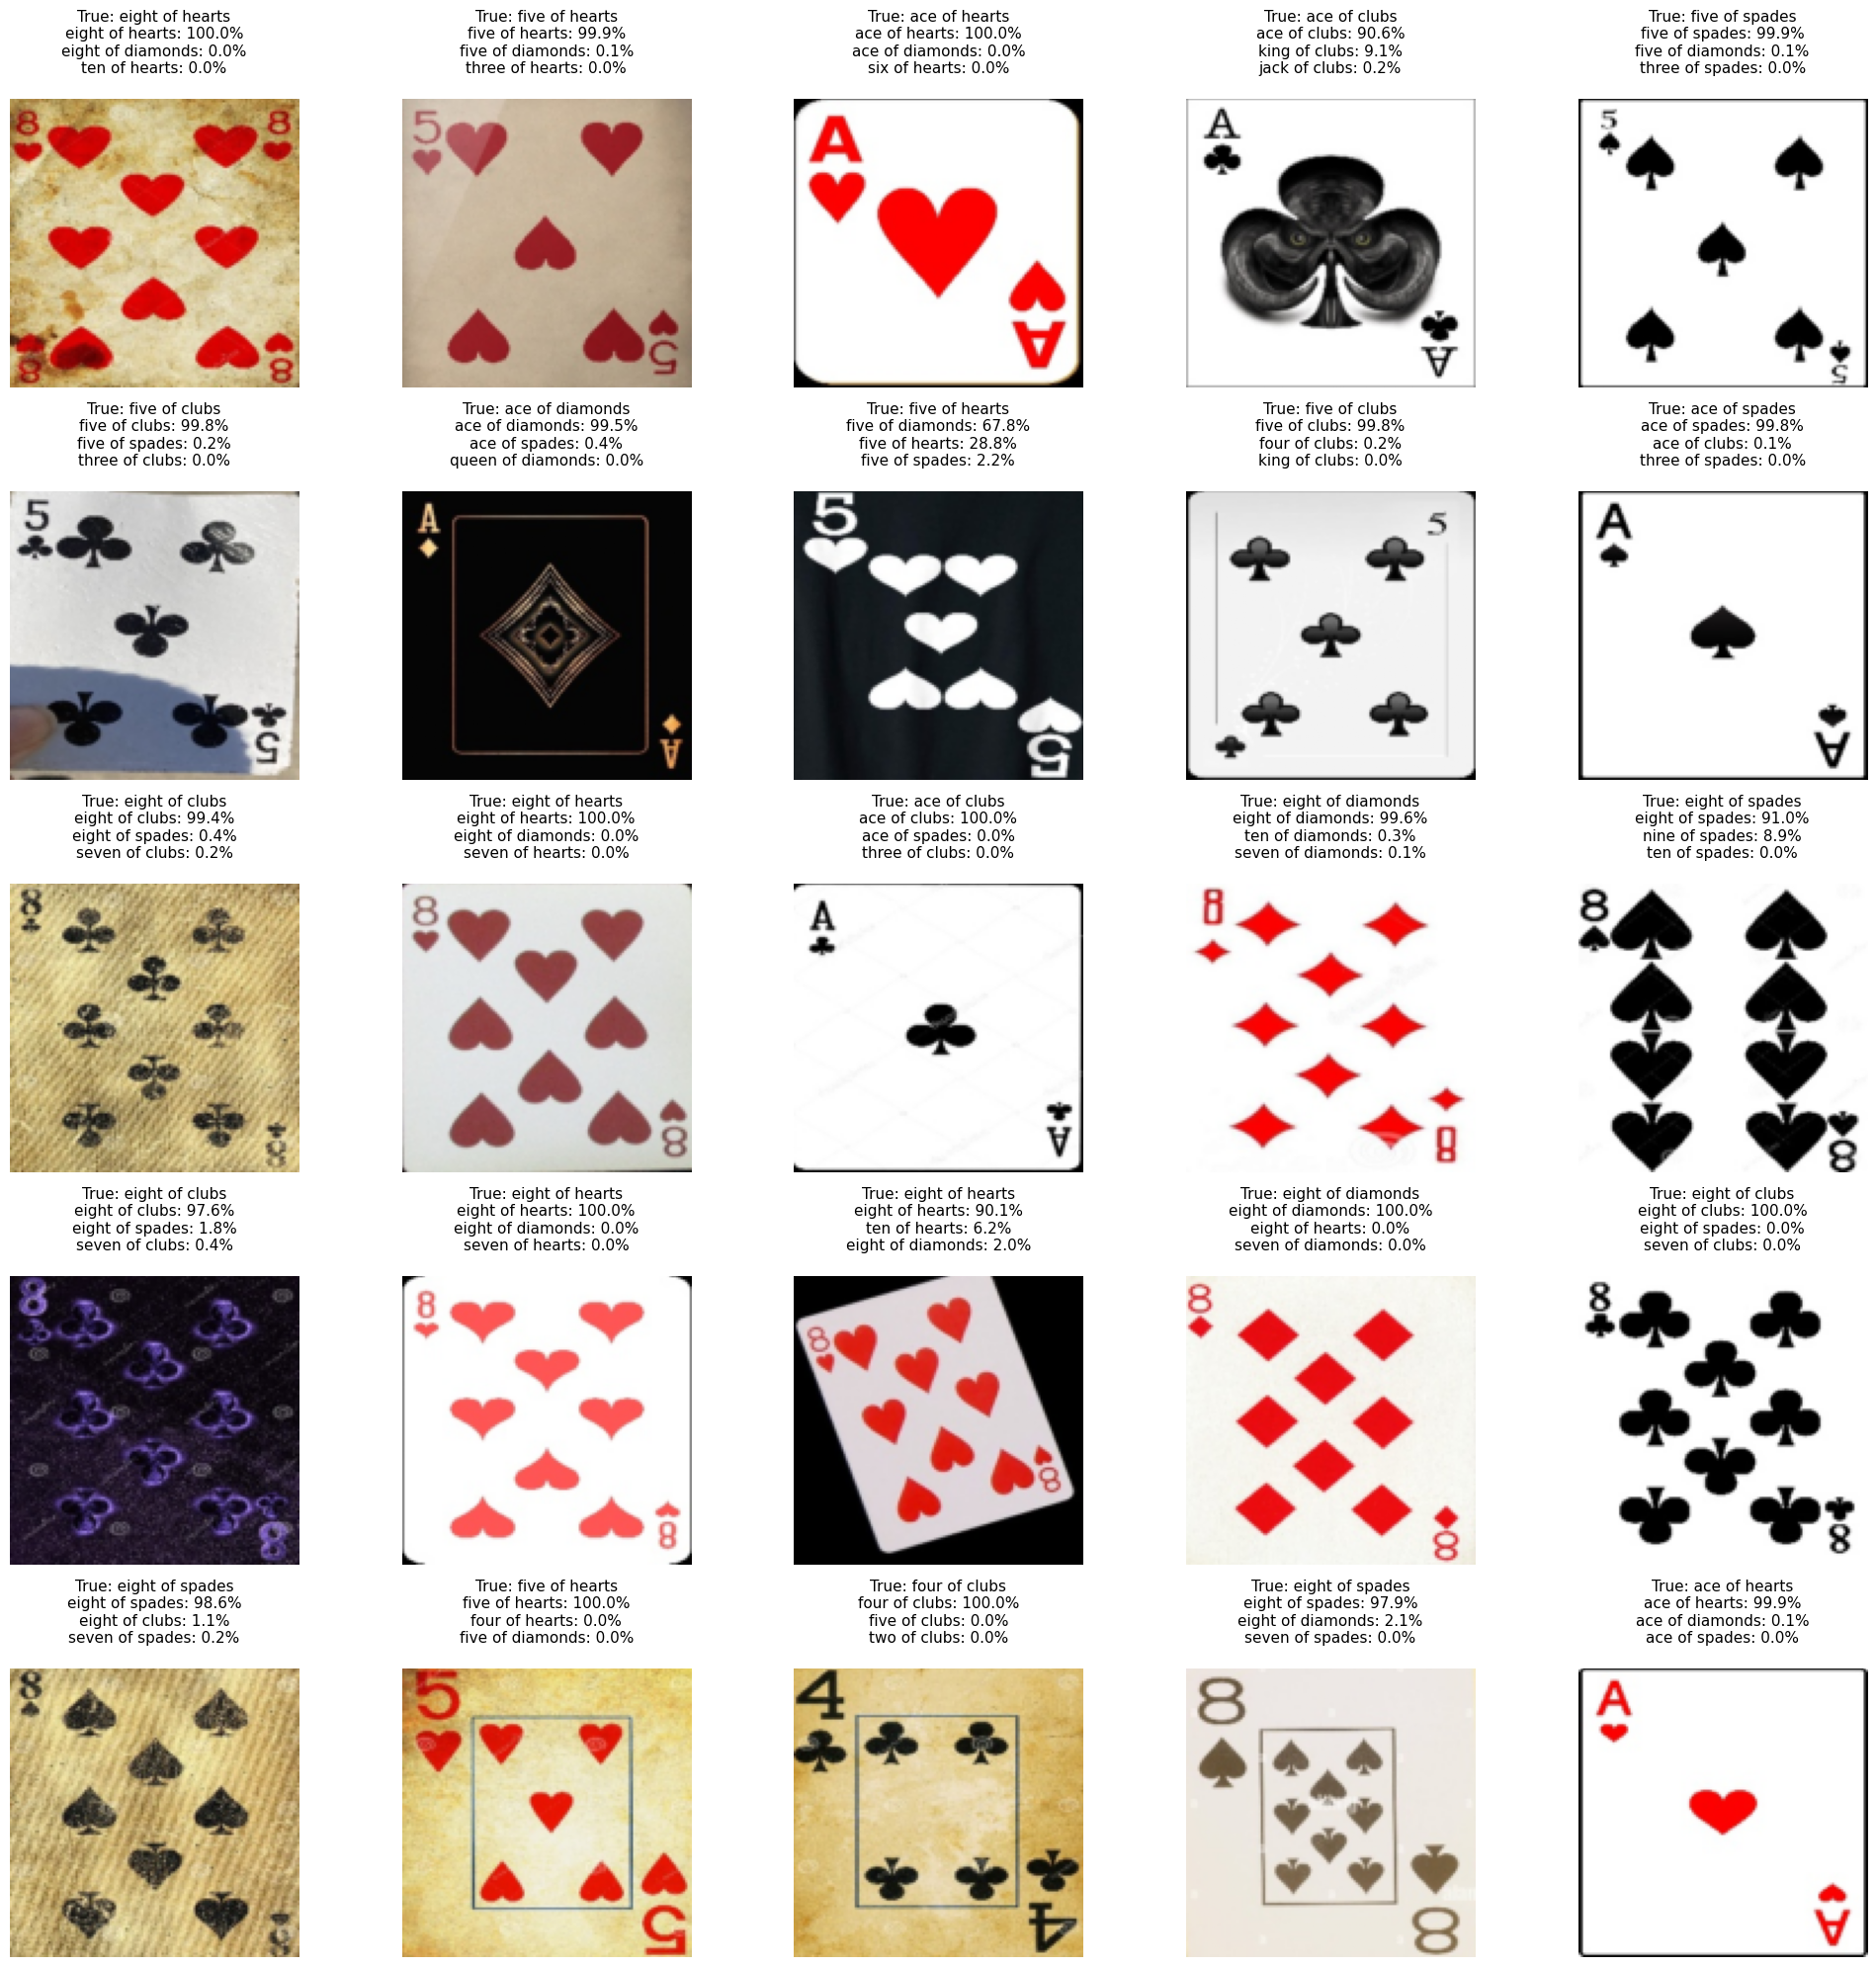

In [48]:
def visualize_multiple_predictions(model, test_loader, class_labels, device, num_images=15):
    # Get all images from a batch
    images, labels = next(iter(test_loader))
    batch_size = len(images)
    
    # Generate random indices
    random_indices = torch.randperm(batch_size)[:num_images]
    
    # Calculate grid dimensions
    num_cols = 5
    num_rows = (num_images + num_cols - 1) // num_cols  # Ceiling division
    
    # Create a figure with a grid of subplots
    fig = plt.figure(figsize=(4*num_cols, 4*num_rows))
    
    for i, idx in enumerate(random_indices):
        # Get randomly selected image and its label
        image = images[idx].unsqueeze(0).to(device)
        true_label = labels[idx].item()
        
        # Get model predictions
        model.eval()
        with torch.no_grad():
            outputs = model(image)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            
        # Get top 3 predictions
        top3_probs, top3_indices = torch.topk(probabilities[0], 3)
        top3_probs = top3_probs.cpu().numpy() * 100
        top3_labels = [class_labels[idx.item()] for idx in top3_indices]
        
        # Create subplot
        ax = plt.subplot(num_rows, num_cols, i + 1)
        
        # Show image
        img = images[idx].permute(1, 2, 0)
        ax.imshow(img)
        ax.axis('off')
        
        # Add predictions as text
        pred_text = f'True: {class_labels[true_label]}\n'
        for prob, label in zip(top3_probs, top3_labels):
            pred_text += f'{label}: {prob:.1f}%\n'
        
        ax.set_title(pred_text, fontsize=11)
    
    plt.tight_layout()
    plt.show()

# Show 15 random predictions
visualize_multiple_predictions(model, test_loader, class_labels, device, num_images=25)

## Save the model


In [ ]:
torch.save(model.state_dict(), "ImgClassif.pth") # Saves the entire state to disk